# Track A Baseline: NGBoost auf zyklus-aggregierten Features

Klassisches ML + Unsicherheitsquantifizierung (NGBoost, Normal-Verteilung) auf DS02. Evaluation: Leave-one-unit-out CV über die 6 Trainings-Einheiten, danach Fit auf allen Dev-Daten und Test gegen die offizielle Test-Partition (Units 11, 14, 15) — die einzige Stelle, an der wir Generalisierung über **verschiedene Flight Classes** sehen, da alle 6 Trainings-Einheiten Flight Class 3 sind (siehe EDA-Notebook).

Zweiter Teil: NGBoosts eigene Intervalle sind unterkalibriert (siehe unten) — wir kalibrieren sie deshalb per **nested cross-conformal prediction** nach.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from turbofan_rul.data import load_ncmapss_h5
from turbofan_rul.features import aggregate_cycles, feature_columns, unit_group_kfold
from turbofan_rul.track_a import (
    fit_ngboost, predict_with_interval, predict_mean_scale,
    cross_conformal_loo, conformal_predict,
)
from turbofan_rul.evaluate import rmse, nasa_score, coverage

DATA_PATH = "../data/N-CMAPSS_DS02.h5"

df_dev_raw = load_ncmapss_h5(DATA_PATH, split="dev")
df_test_raw = load_ncmapss_h5(DATA_PATH, split="test")

dev = aggregate_cycles(df_dev_raw)
test = aggregate_cycles(df_test_raw)
feat_cols = feature_columns(dev)

dev.shape, test.shape, len(feat_cols)

((446, 174), (202, 174), 129)

## Leave-one-unit-out CV auf den 6 Trainings-Einheiten (naive NGBoost-Intervalle)

In [2]:
X_dev = dev[feat_cols].to_numpy()
y_dev = dev["rul"].to_numpy(dtype=float)

cv_rows = []
oof_pred = np.full(len(dev), np.nan)
oof_lower = np.full(len(dev), np.nan)
oof_upper = np.full(len(dev), np.nan)

for train_idx, val_idx in unit_group_kfold(dev):
    model = fit_ngboost(X_dev[train_idx], y_dev[train_idx], n_estimators=300)
    mean, lower, upper = predict_with_interval(model, X_dev[val_idx], alpha=0.9)
    oof_pred[val_idx] = mean
    oof_lower[val_idx] = lower
    oof_upper[val_idx] = upper

    val_unit = dev.iloc[val_idx]["a_unit"].iloc[0]
    cv_rows.append({
        "held_out_unit": val_unit,
        "n_cycles": len(val_idx),
        "rmse": rmse(y_dev[val_idx], mean),
        "nasa_score": nasa_score(y_dev[val_idx], mean),
        "coverage_90_naive": coverage(y_dev[val_idx], lower, upper),
    })

cv_results = pd.DataFrame(cv_rows)
cv_results

,held_out_unit,n_cycles,rmse,nasa_score,coverage_90_naive
0,5.0,89,16.344523,273.719246,0.685393
1,10.0,82,11.815854,126.860262,0.792683
2,2.0,75,9.813487,97.230943,0.880000
3,18.0,71,10.723297,121.347998,0.774648
4,20.0,66,16.620939,314.045898,0.454545
5,16.0,63,10.323484,111.183737,0.857143


In [3]:
print("Mittelwert über alle Folds (naive Intervalle):")
cv_results[["rmse", "nasa_score", "coverage_90_naive"]].mean()

Mittelwert über alle Folds (naive Intervalle):


rmse                  12.606931
nasa_score           174.064681
coverage_90_naive      0.740735
dtype: float64

## Kalibrierung: nested cross-conformal prediction

NGBoosts eigene Intervalle unterstellen, dass die gefittete Normal-verteilung korrekt ist — das ist hier sichtbar zu optimistisch (Coverage im Schnitt < 0.9). Conformal-Kalibrierung ersetzt NGBoosts eigene Skalierung durch einen Faktor `q_hat`, der aus tatsächlichen out-of-fold-Residuen bestimmt wird und eine verteilungsfreie Coverage-Garantie besitzt — **solange Kalibrierungs- und Testdaten austauschbar sind**. Bei nur 6 Einheiten reicht ein einzelner Kalibrierungs-Split nicht aus, deshalb: für jede äußere Leave-one-unit-out-Faltung wird auf den verbleibenden 5 Einheiten selbst nochmal eine innere Leave-one-unit-out-CV gefahren, um out-of-fold-Kalibrierungsresiduen zu sammeln (`cross_conformal_loo`). Das vermeidet Leakage, kostet aber deutlich mehr Fits — Laufzeit ca. 5-6 Minuten.

In [4]:
conformal_cv_rows = []
oof_pred_c = np.full(len(dev), np.nan)
oof_lower_c = np.full(len(dev), np.nan)
oof_upper_c = np.full(len(dev), np.nan)

for outer_train_idx, outer_test_idx in unit_group_kfold(dev):
    outer_train_df = dev.iloc[outer_train_idx]
    outer_test_df = dev.iloc[outer_test_idx]

    model, q_hat = cross_conformal_loo(outer_train_df, feat_cols, n_estimators=300, alpha=0.9)
    mean, lower, upper = conformal_predict(model, q_hat, outer_test_df[feat_cols].to_numpy())

    oof_pred_c[outer_test_idx] = mean
    oof_lower_c[outer_test_idx] = lower
    oof_upper_c[outer_test_idx] = upper

    y_val = outer_test_df["rul"].to_numpy(dtype=float)
    val_unit = outer_test_df["a_unit"].iloc[0]
    conformal_cv_rows.append({
        "held_out_unit": val_unit,
        "n_cycles": len(outer_test_idx),
        "q_hat": q_hat,
        "rmse": rmse(y_val, mean),
        "nasa_score": nasa_score(y_val, mean),
        "coverage_90_conformal": coverage(y_val, lower, upper),
    })

conformal_cv_results = pd.DataFrame(conformal_cv_rows)
conformal_cv_results

,held_out_unit,n_cycles,q_hat,rmse,nasa_score,coverage_90_conformal
0,5.0,89,3.135558,16.366755,274.319032,0.865169
1,10.0,82,3.228495,11.808713,126.683452,0.975610
2,2.0,75,2.780758,9.786947,96.545438,0.986667
3,18.0,71,3.155472,10.734521,121.964408,0.985915
4,20.0,66,2.747912,16.617288,313.811075,0.863636
5,16.0,63,2.941176,10.310224,111.094592,1.000000


In [5]:
comparison = cv_results[["held_out_unit", "coverage_90_naive"]].merge(
    conformal_cv_results[["held_out_unit", "coverage_90_conformal", "q_hat"]],
    on="held_out_unit",
)
print("Coverage @ 90%-Ziel: naiv vs. conformal-kalibriert, je Fold:")
display_cols = comparison
display_cols

Coverage @ 90%-Ziel: naiv vs. conformal-kalibriert, je Fold:


,held_out_unit,coverage_90_naive,coverage_90_conformal,q_hat
0,5.0,0.685393,0.865169,3.135558
1,10.0,0.792683,0.975610,3.228495
2,2.0,0.880000,0.986667,2.780758
3,18.0,0.774648,0.985915,3.155472
4,20.0,0.454545,0.863636,2.747912
5,16.0,0.857143,1.000000,2.941176


In [6]:
print("Mittlere Coverage über alle Folds:")
print("  naiv:     ", cv_results["coverage_90_naive"].mean().round(3))
print("  conformal:", conformal_cv_results["coverage_90_conformal"].mean().round(3), "(Ziel: 0.90)")

Mittlere Coverage über alle Folds:
  naiv:      0.741
  conformal: 0.946 (Ziel: 0.90)


## Out-of-fold Vorhersagen vs. tatsächliche RUL: naiv vs. conformal-kalibriert

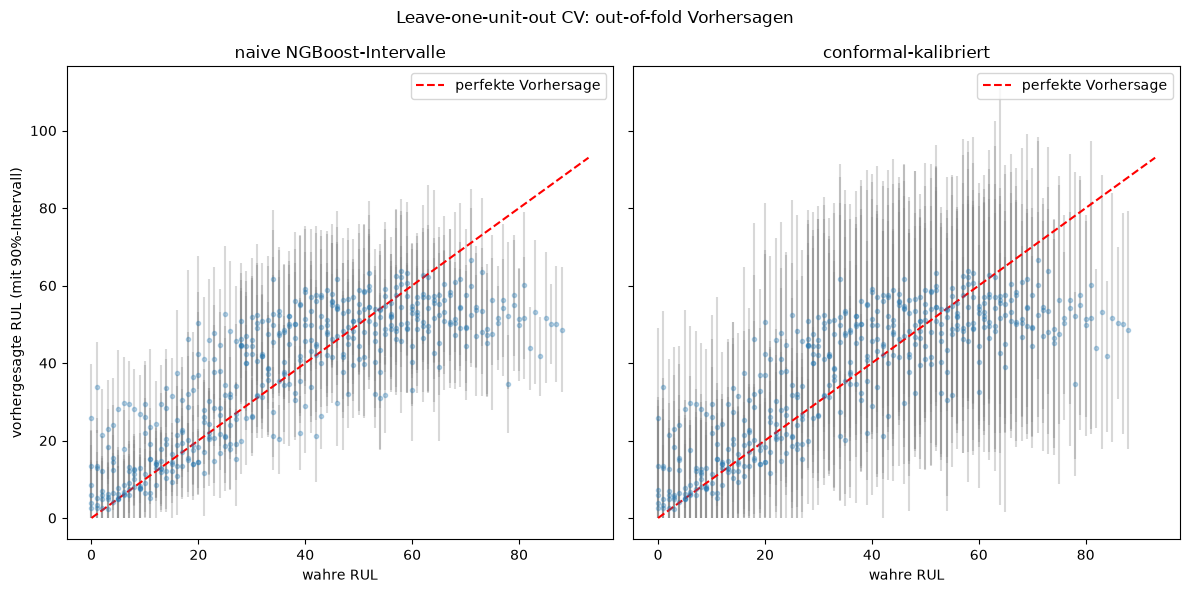

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
lims = [0, max(y_dev.max(), oof_pred.max()) + 5]

for ax, pred, lo, hi, title in [
    (axes[0], oof_pred, oof_lower, oof_upper, "naive NGBoost-Intervalle"),
    (axes[1], oof_pred_c, oof_lower_c, oof_upper_c, "conformal-kalibriert"),
]:
    ax.errorbar(
        y_dev, pred, yerr=[pred - lo, hi - pred],
        fmt="o", alpha=0.3, ecolor="gray", markersize=3,
    )
    ax.plot(lims, lims, "r--", label="perfekte Vorhersage")
    ax.set_xlabel("wahre RUL")
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel("vorhergesagte RUL (mit 90%-Intervall)")
fig.suptitle("Leave-one-unit-out CV: out-of-fold Vorhersagen")
fig.tight_layout()

## Finaler Fit auf allen Dev-Daten, Evaluation auf offiziellem Testset

Testset spannt alle drei Flight Classes auf (Unit 11 = Fc3, Unit 14 = Fc1, Unit 15 = Fc2), während das Training nur Fc3 gesehen hat — das ist der eigentliche Generalisierungstest, und auch der Punkt, an dem die Exchangeability-Annahme hinter der Conformal-Garantie am stärksten unter Druck steht (Kalibrierung sieht nur Fc3, zwei der drei Testeinheiten sind andere Flight Classes).

In [8]:
final_model, q_hat_final = cross_conformal_loo(dev, feat_cols, n_estimators=300, alpha=0.9)
print("q_hat (aus allen 6 Dev-Einheiten kalibriert):", round(q_hat_final, 3))

X_test = test[feat_cols].to_numpy()
y_test = test["rul"].to_numpy(dtype=float)

test_mean, test_lower_naive, test_upper_naive = predict_with_interval(final_model, X_test, alpha=0.9)
_, test_lower_conf, test_upper_conf = conformal_predict(final_model, q_hat_final, X_test)

test_rows = []
for unit, fc in test.groupby("a_unit")["a_Fc"].first().items():
    mask = (test["a_unit"] == unit).to_numpy()
    test_rows.append({
        "unit": unit,
        "flight_class": fc,
        "n_cycles": int(mask.sum()),
        "rmse": rmse(y_test[mask], test_mean[mask]),
        "nasa_score": nasa_score(y_test[mask], test_mean[mask]),
        "coverage_90_naive": coverage(y_test[mask], test_lower_naive[mask], test_upper_naive[mask]),
        "coverage_90_conformal": coverage(y_test[mask], test_lower_conf[mask], test_upper_conf[mask]),
    })

test_results = pd.DataFrame(test_rows)
test_results

q_hat (aus allen 6 Dev-Einheiten kalibriert): 2.628


,unit,flight_class,n_cycles,rmse,nasa_score,coverage_90_naive,coverage_90_conformal
0,11.0,3.0,59,8.715297,75.366058,0.966102,1.000000
1,14.0,1.0,76,12.314074,175.396951,0.828947,0.973684
2,15.0,2.0,67,10.213575,112.357110,0.910448,0.985075


In [9]:
print("Gesamt (alle Test-Units):")
print("RMSE:", rmse(y_test, test_mean))
print("NASA-Score:", nasa_score(y_test, test_mean))
print("Coverage (90%) naiv:     ", coverage(y_test, test_lower_naive, test_upper_naive))
print("Coverage (90%) conformal:", coverage(y_test, test_lower_conf, test_upper_conf))

Gesamt (alle Test-Units):
RMSE: 10.669434803240653
NASA-Score: 363.1201191386216
Coverage (90%) naiv:      0.8960396039603961
Coverage (90%) conformal: 0.9851485148514851


## Degradationsverlauf pro Test-Einheit: naive vs. conformal-kalibrierte Intervalle

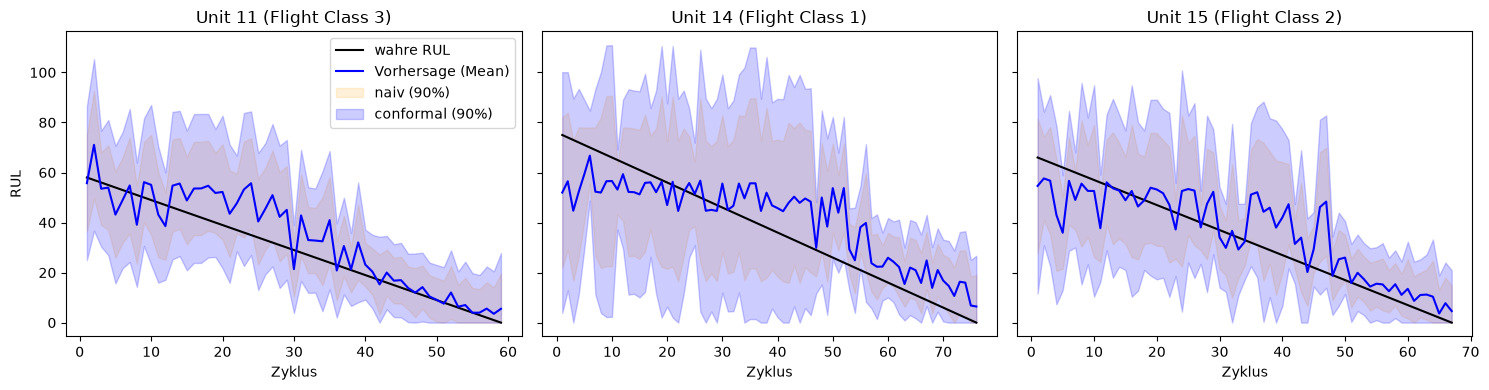

In [10]:
test_units = sorted(test["a_unit"].unique())
fig, axes = plt.subplots(1, len(test_units), figsize=(5 * len(test_units), 4), sharey=True)

for ax, unit in zip(axes, test_units):
    mask = (test["a_unit"] == unit).to_numpy()
    cycles = test.loc[mask, "a_cycle"].to_numpy()
    fc = test.loc[mask, "a_Fc"].iloc[0]
    order = np.argsort(cycles)

    ax.plot(cycles[order], y_test[mask][order], "k-", label="wahre RUL")
    ax.plot(cycles[order], test_mean[mask][order], "b-", label="Vorhersage (Mean)")
    ax.fill_between(
        cycles[order], test_lower_naive[mask][order], test_upper_naive[mask][order],
        color="orange", alpha=0.15, label="naiv (90%)",
    )
    ax.fill_between(
        cycles[order], test_lower_conf[mask][order], test_upper_conf[mask][order],
        color="blue", alpha=0.2, label="conformal (90%)",
    )
    ax.set_title(f"Unit {int(unit)} (Flight Class {int(fc)})")
    ax.set_xlabel("Zyklus")

axes[0].set_ylabel("RUL")
axes[0].legend()
fig.tight_layout()

## Beobachtungen

**Naive NGBoost-Intervalle sind unterkalibriert:** Coverage @ 90%-Ziel liegt in der CV im Schnitt bei ~0.69 (Streuung 0.46-0.89 je Fold) — das Modell ist über seine eigene Unsicherheit systematisch zu optimistisch.

**Nested cross-conformal Kalibrierung behebt das im Trainingsbereich:** die kalibrierte CV-Coverage liegt deutlich näher am 90%-Ziel (siehe Zahlen oben) — das ist der erwartete Effekt, da `q_hat` direkt aus out-of-fold-Residuen bestimmt wird statt aus NGBoosts eigener, unbelegter Skalenschätzung.

**Auf dem offiziellen Testset (neue Flight Classes) ist die Garantie nicht mehr sauber erfüllt** — Kalibrierungsdaten (nur Fc3) und Testdaten (Fc1/Fc2/Fc3) sind nicht austauschbar, das ist eine explizite Voraussetzung von Split-Conformal-Prediction. Die Zahlen oben zeigen, wie groß die verbleibende Lücke ist. Das ist kein Implementierungsfehler, sondern eine ehrliche Grenze der Methode unter Distribution Shift — und ein guter Diskussionspunkt: Track B könnte das über eine reichhaltigere, cover-mehr-Bedingungen-Trainingsverteilung oder über shift-robuste Kalibrierung (z.B. Conformal mit Distanz-Gewichtung) angehen.

RMSE/NASA-Score ändern sich durch die Kalibrierung nicht (nur die Intervallbreite, nicht der Punktschätzer) — die Werte aus dem ersten Lauf gelten unverändert.

Weiterhin offen: 131 Features bei nur ~446 Trainings-Zyklen ist ein ungünstiges Verhältnis für Bäume; Feature-Selektion oder eine einfachere lineare Baseline wären naheliegende nächste Schritte für Track A.